In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier
from time import time
from sklearn.svm import SVC
from sklearn import svm
from mlxtend.classifier import StackingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import numpy as np
from statistics import mode
from scipy.stats import kurtosis, skew
import statistics
import struct
import ast
from time import time
from sklearn.metrics import confusion_matrix
import itertools

from ast import literal_eval
from sklearn.ensemble import IsolationForest
import pandas as pd
import glob
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import sklearn
from sklearn.multiclass import OneVsRestClassifier
from time import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import classification_report
import numpy as np
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score,roc_curve, precision_recall_curve, auc, make_scorer, recall_score, accuracy_score, precision_score, confusion_matrix
from sklearn.metrics import roc_auc_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn import model_selection
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
from collections import Counter
import time
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from IPython.core.pylabtools import figsize
# Load Library
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
dos = pd.read_csv(r'/kaggle/input/cicids-2017/DoS_Attack.csv')
dos[' Label'].value_counts()

 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

In [ ]:
dos[' Label'] = dos[' Label'].replace({
    'DoS Hulk': 'DoS',
    'DDoS': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'Heartbleed': 'DoS'
})

In [ ]:
ddos = pd.read_csv(r'/kaggle/input/cicids-2017/DDoS_Attack.csv')

ddos[' Label'].value_counts()

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

In [ ]:
bruteforce = pd.read_csv(r'/kaggle/input/cicids-2017/Brute_Force.csv')

bruteforce[' Label'].value_counts()

 Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

In [ ]:
bruteforce[' Label'] = bruteforce[' Label'].replace({
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce'
})
bruteforce[' Label'].value_counts()

 Label
BENIGN        432074
BruteForce     13835
Name: count, dtype: int64

In [ ]:
portscan = pd.read_csv(r'/kaggle/input/cicids-2017/PortScan_Attack.csv')

portscan[' Label'].value_counts()

 Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64

In [ ]:
df = pd.concat([dos, ddos, bruteforce, portscan])
df[' Label'].value_counts()

 Label
BENIGN        1097360
DoS            252672
PortScan       158930
DDoS           128027
BruteForce      13835
Name: count, dtype: int64

In [ ]:
df.head(2)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df[' Label'].value_counts()

 Label
BENIGN        1097360
DoS            252672
PortScan       158930
DDoS           128027
BruteForce      13835
Name: count, dtype: int64

In [ ]:
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False])

In [ ]:
df = df.drop(columns=' Fwd Header Length.1')

In [ ]:
df.shape

(1650824, 78)

In [ ]:
df.columns=df.columns.str.strip()

In [ ]:
df.loc[:,'Label'].unique()

array(['BENIGN', 'DoS', 'DDoS', 'BruteForce', 'PortScan'], dtype=object)

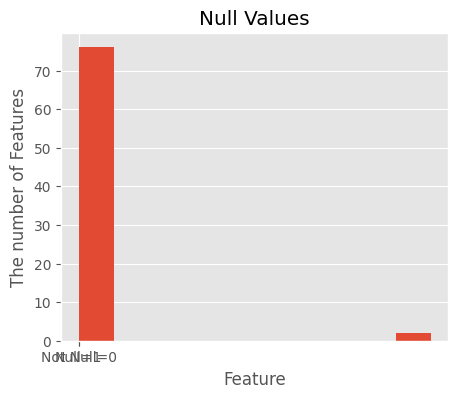

In [ ]:
plt.figure(1,figsize=( 5,4))
plt.hist(df.isna().sum())
plt.xticks([0,1], labels=['Not Null=0', 'Null=1'])
plt.title('Null Values')
plt.xlabel('Feature')
plt.ylabel('The number of Features')
plt.show()

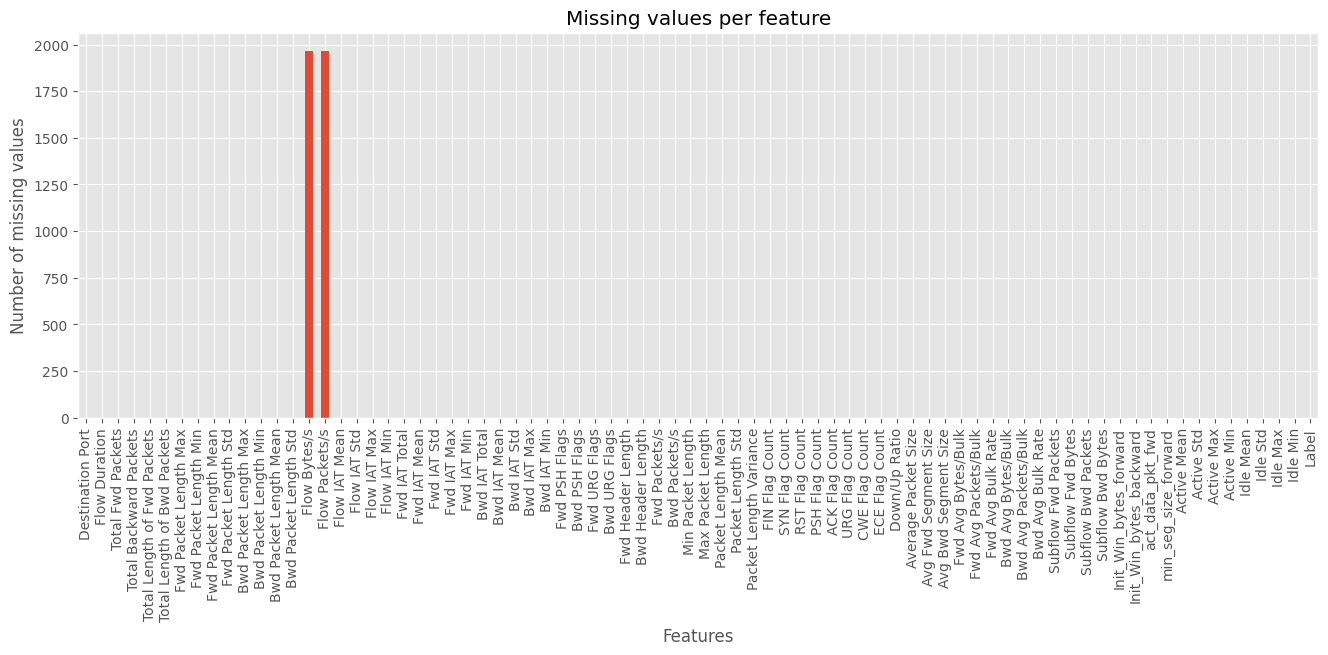

In [ ]:
def plotmissingvalues(dataframe):
    missingvalues=dataframe.isnull().sum()
    fig=plt.figure(figsize=(16,5))
    missingvalues.plot.bar()
    plt.xlabel("Features")
    plt.ylabel("Number of missing values")
    plt.title("Missing values per feature")
    plt.show()

plotmissingvalues(df)

In [ ]:
# Drop all Null Values
data_f=df.dropna()
data_f.shape

(1648858, 78)

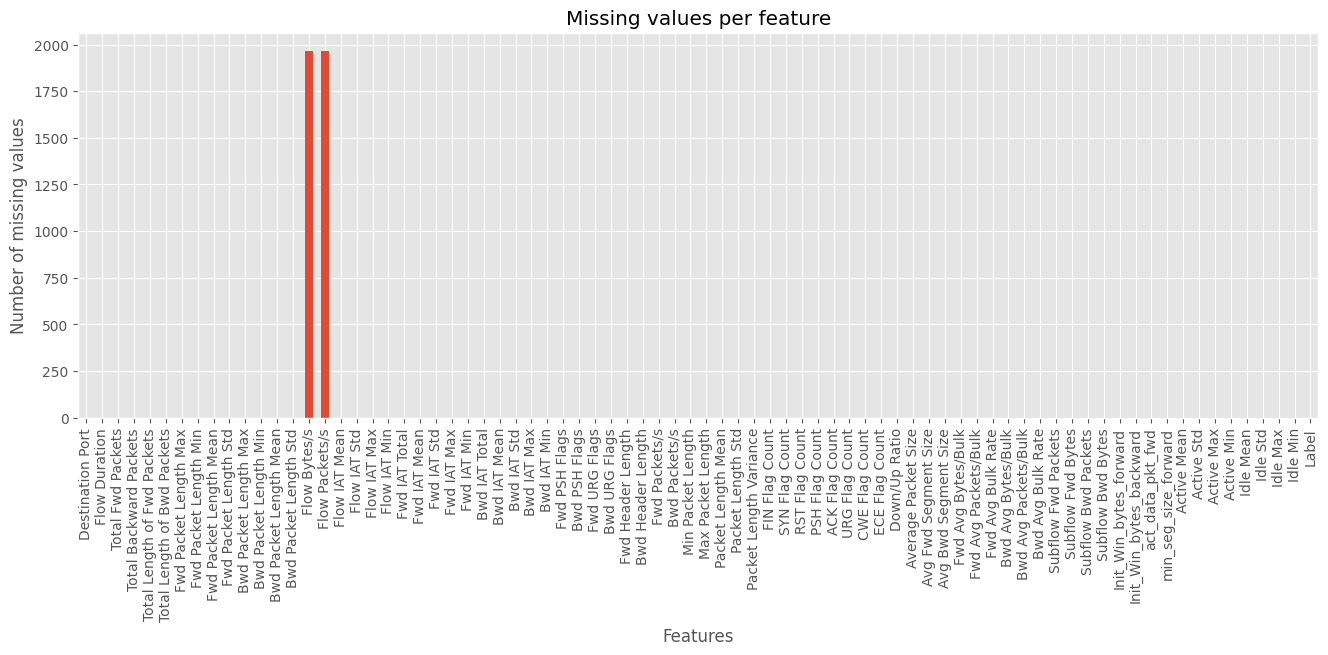

In [ ]:
def plotmissingvalues(dataframe):
    missingvalues=dataframe.isnull().sum()
    fig=plt.figure(figsize=(16,5))
    missingvalues.plot.bar()
    plt.xlabel("Features")
    plt.ylabel("Number of missing values")
    plt.title("Missing values per feature")
    plt.show()

plotmissingvalues(df)

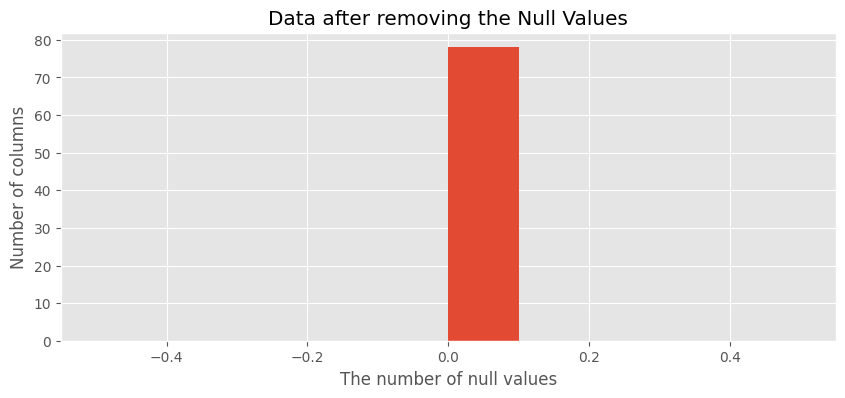

In [ ]:
#Checking the null values in the dataset.
plt.figure(1,figsize=( 10,4))
plt.hist( data_f.isna().sum())
# Set the title and axis labels
plt.title('Data after removing the Null Values')
plt.xlabel('The number of null values')
plt.ylabel('Number of columns')

# Show the plot
plt.show()

In [ ]:
pd.set_option('use_inf_as_na', True)
nullvalues=df.isnull().sum()
nullvalues

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 78, dtype: int64

In [ ]:
(data_f.dtypes=='object')

Destination Port               False
Flow Duration                  False
Total Fwd Packets              False
Total Backward Packets         False
Total Length of Fwd Packets    False
                               ...  
Idle Mean                      False
Idle Std                       False
Idle Max                       False
Idle Min                       False
Label                           True
Length: 78, dtype: bool

In [ ]:
data_f['Label']=data_f['Label'].map({'BENIGN':0, 'DoS':1, 'DDoS':2, 'BruteForce':3, 'PortScan' :4})

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (4).

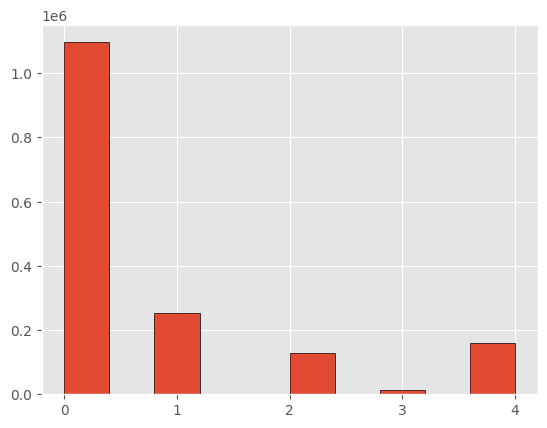

In [ ]:
plt.hist(data_f['Label'],edgecolor='black')
plt.xticks([0,1,2,3,4], labels=['BENIGN=0','DoS=1','DDoS=2','BruteForce=3''PortScan=4'])
plt.xlabel('classes')
plt.ylabel('Count')
plt.show()

In [ ]:
data_f.shape

(1648858, 78)

In [ ]:
#Check for duplicate values
dups=data_f[data_f.duplicated()]
print(len(dups))

198526


In [ ]:
# Remove all duplicate values
data_f.drop_duplicates(inplace=True)
data_f.shape

(1450332, 78)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Split data into features and target variable
X = data_f.drop('Label', axis=1)
y = data_f['Label']

selector = SelectKBest(score_func=f_classif, k=25)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

# Print the selected features
print("Selected Features:")
print(selected_features)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.30, random_state=42)
y_test.value_counts()
y_train.value_counts()

Selected Features:
Index(['Flow Duration', 'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Max',
       'Idle Min'],
      dtype='object')


Label
0    720139
1    135728
2     89524
4     63451
3      6390
Name: count, dtype: int64

In [ ]:
X_selected.shape

(1450332, 25)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import HistGradientBoostingClassifier

# Gradient Boosting model training
gradclf = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
gradclf.fit(X_train, y_train)
rf_predicted =gradclf.predict(X_test)
accuracy = accuracy_score(y_test,rf_predicted)
print ("Accuracy: ", accuracy)

Accuracy:  0.9994989657549989


In [ ]:
# Evaluation metrics
accuracy = accuracy_score(y_test, rf_predicted)
f1 = f1_score(y_test, rf_predicted, average='weighted')
precision = precision_score(y_test, rf_predicted, average='weighted')
recall = recall_score(y_test, rf_predicted, average='weighted')
print(classification_report(y_test, rf_predicted))


print(f"Accuracy: {accuracy:}")
print(f"Precision: {precision:}")
print(f"Recall: {recall:}")
print(f"F1 Score: {f1:}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    308579
           1       1.00      1.00      1.00     58028
           2       1.00      1.00      1.00     38490
           3       1.00      1.00      1.00      2760
           4       1.00      1.00      1.00     27243

    accuracy                           1.00    435100
   macro avg       1.00      1.00      1.00    435100
weighted avg       1.00      1.00      1.00    435100

Accuracy: 0.9994989657549989
Precision: 0.9995001154519154
Recall: 0.9994989657549989
F1 Score: 0.9994992273379063


<function matplotlib.pyplot.show(close=None, block=None)>

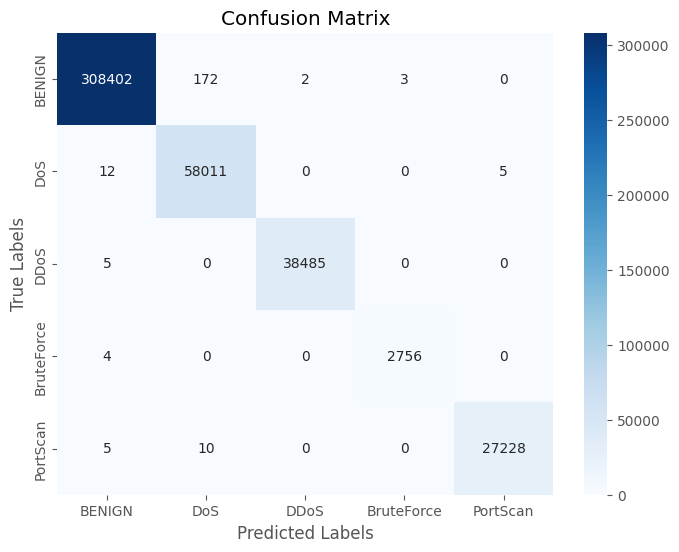

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, rf_predicted)

class_labels = ['BENIGN', 'DoS', 'DDoS','BruteForce', 'PortScan']
# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Under sampling the benign class
undersampler=RandomUnderSampler(sampling_strategy={0: 140000}, random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train,y_train)

X_train_resampled.shape

(435093, 25)

In [ ]:
# scaling the data using standard scaler
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)


In [ ]:
# define knn classifier
Knn_clf=KNeighborsClassifier(n_neighbors=49, algorithm="ball_tree", n_jobs=-1)

In [ ]:
from sklearn.svm import LinearSVC

# define svm classifier
svm_clf=LinearSVC(class_weight="balanced")

In [ ]:
# define Gaussian Naive Bayes classifier
nb_model = GaussianNB()

In [ ]:
# define voting method and train the model using voting classifier
voting_clf=VotingClassifier(estimators=[('SVM',svm_clf), ("NaiveBayes",nb_model), ("KNN", Knn_clf)], voting='hard')
voting_clf.fit(X_train_resampled,y_train_resampled)

voting_pred=voting_clf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,voting_pred))

Accuracy: 0.9770121811077913


In [ ]:
print("Classification Report:\n", classification_report(y_test, voting_pred))

#evaluation metrics
accuracy = accuracy_score(y_test, voting_pred)
f1 = f1_score(y_test, voting_pred, average='weighted')
precision = precision_score(y_test, voting_pred, average='weighted')
recall = recall_score(y_test, voting_pred, average='weighted')

print(f"Accuracy: {accuracy:}")
print(f"Precision: {precision:}")
print(f"Recall: {recall:}")
print(f"F1 Score: {f1:}")

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    308579
           1       1.00      0.94      0.97     58028
           2       0.84      1.00      0.91     38490
           3       0.89      1.00      0.94      2760
           4       0.96      1.00      0.98     27243

    accuracy                           0.98    435100
   macro avg       0.94      0.98      0.96    435100
weighted avg       0.98      0.98      0.98    435100

Accuracy: 0.9770121811077913
Precision: 0.9798769468562593
Recall: 0.9770121811077913
F1 Score: 0.9776257167799962


<function matplotlib.pyplot.show(close=None, block=None)>

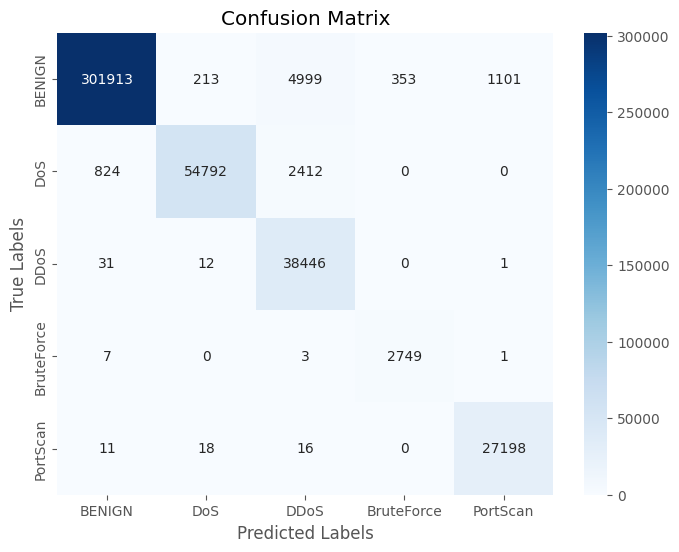

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, voting_pred)

class_labels = ['BENIGN', 'DoS', 'DDoS','BruteForce', 'PortScan']
# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the MLP model
def build_mlp(input_shape, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),  # First hidden layer
        Dropout(0.3),  # Dropout for regularization
        Dense(64, activation='relu'),  # Second hidden layer
        Dropout(0.3),
        Dense(32, activation='relu'),  # Third hidden layer
        Dense(num_classes, activation='softmax')  # Output layer
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Get input shape and number of classes
input_shape = X_train_resampled.shape[1]
num_classes = len(set(y_train_resampled))  # Adjust for multi-class or binary classification

# Build and train the model
model = build_mlp(input_shape, num_classes)
history = model.fit(X_train_resampled, y_train_resampled, validation_data=(X_test, y_test), epochs=20, batch_size=256)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9067 - loss: 0.2746 - val_accuracy: 0.9731 - val_loss: 0.0577
Epoch 2/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9828 - loss: 0.0509 - val_accuracy: 0.9767 - val_loss: 0.0472
Epoch 3/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9855 - loss: 0.0411 - val_accuracy: 0.9785 - val_loss: 0.0460
Epoch 4/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9867 - loss: 0.0374 - val_accuracy: 0.9824 - val_loss: 0.0318
Epoch 5/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9879 - loss: 0.0331 - val_accuracy: 0.9812 - val_loss: 0.0359
Epoch 6/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9880 - loss: 0.0327 - val_accuracy: 0.9806 - val_loss: 0.0355
Epoch 7/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9890 - loss: 0.0315 - val_accuracy: 0.9814 - val_loss: 0.0395
Epoch 8/20
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9894 - loss: 0

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Make predictions
y_pred = model.predict(X_test)

# Convert predictions to class labels
if num_classes > 2:
    y_pred_labels = np.argmax(y_pred, axis=1)  # For multi-class classification
    average_type = 'weighted'  # Use 'weighted' to handle class imbalance
else:
    y_pred_labels = (y_pred > 0.5).astype(int)  # For binary classification
    average_type = 'binary'

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_labels)
precision = precision_score(y_test, y_pred_labels, average=average_type)
recall = recall_score(y_test, y_pred_labels, average=average_type)
f1 = f1_score(y_test, y_pred_labels, average=average_type)


# Print full classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_labels))

# Print metrics
print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1-score:  {f1}")


13597/13597 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    308579
           1       0.94      1.00      0.97     58028
           2       0.99      1.00      0.99     38490
           3       0.94      0.99      0.96      2760
           4       1.00      1.00      1.00     27243

    accuracy                           0.99    435100
   macro avg       0.97      0.99      0.98    435100
weighted avg       0.99      0.99      0.99    435100

Accuracy:  0.9895656170995174
Precision: 0.9900760902953605
Recall:    0.9895656170995174
F1-score:  0.9896671397997394


<function matplotlib.pyplot.show(close=None, block=None)>

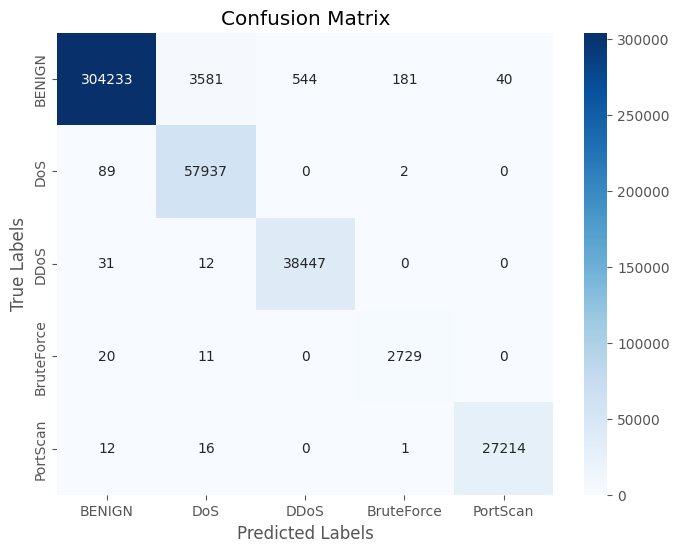

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)

class_labels = ['BENIGN', 'DoS', 'DDoS','BruteForce', 'PortScan']
# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show

In [ ]:
import pickle

# Assuming 'model' is your trained ML model
model_filename = "gradclf.pkl"

# Save the model using pickle
with open(model_filename, 'wb') as file:
    pickle.dump(gradclf, file)

print(f"Model saved as {model_filename}")
